In [44]:
import kagglehub
import pandas as pd
from pandasql import sqldf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [2]:
# Download latest version from Kaggle
path = kagglehub.dataset_download("behrad3d/nasa-cmaps")

print("Path to dataset files:", path)

Path to dataset files: /home/dbyun/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1


In [3]:
def filter_novar(df):
    pysqldf_local = lambda q: sqldf(q,globals())
    query_start = "SELECT "
    #unfortunately wasn't able to avoid hardcoding the dataframe name. Will explore options
    query_end = " FROM df_1"
    for col in df:
        added_str = "MAX("+col+")-MIN("+col+")"
        as_str = col
        query_start = query_start+added_str+" as "+col
        if col != "RUL":
            query_start+=","
    q = query_start+query_end
    print(q)
    return pysqldf_local(q)

In [4]:
df_1 = pd.read_csv("train_FD001.txt",sep=' ',header=None)

In [5]:
df_1 = df_1.dropna(axis=1)

In [6]:
#Name the columns according to the README file for the dataset
columns = ['unit_id','cycle','op_set1','op_set2','op_set3']+[f's{i}' for i in range(1, 22)]
df_1.columns = columns

In [7]:
df_1

,unit_id,cycle,op_set1,op_set2,op_set3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


In [8]:
#Find max cycle for each unit
max_cycles = df_1.groupby('unit_id')['cycle'].transform('max')

#Calculate RUL
df_1['RUL'] = max_cycles-df_1['cycle']

In [9]:
#Use pandasql to filter data with SQL queries


pysqldf = lambda q: sqldf(q,globals())

#Filter out columns with no variance
#Outputs columns with zero variance
df_1_filter = filter_novar(df_1)


#Create list of columns to drop
cols_to_drop = []
for col in df_1_filter:
    if df_1_filter[col][0]==0:
        cols_to_drop.append(col)

cols_to_drop

SELECT MAX(unit_id)-MIN(unit_id) as unit_id,MAX(cycle)-MIN(cycle) as cycle,MAX(op_set1)-MIN(op_set1) as op_set1,MAX(op_set2)-MIN(op_set2) as op_set2,MAX(op_set3)-MIN(op_set3) as op_set3,MAX(s1)-MIN(s1) as s1,MAX(s2)-MIN(s2) as s2,MAX(s3)-MIN(s3) as s3,MAX(s4)-MIN(s4) as s4,MAX(s5)-MIN(s5) as s5,MAX(s6)-MIN(s6) as s6,MAX(s7)-MIN(s7) as s7,MAX(s8)-MIN(s8) as s8,MAX(s9)-MIN(s9) as s9,MAX(s10)-MIN(s10) as s10,MAX(s11)-MIN(s11) as s11,MAX(s12)-MIN(s12) as s12,MAX(s13)-MIN(s13) as s13,MAX(s14)-MIN(s14) as s14,MAX(s15)-MIN(s15) as s15,MAX(s16)-MIN(s16) as s16,MAX(s17)-MIN(s17) as s17,MAX(s18)-MIN(s18) as s18,MAX(s19)-MIN(s19) as s19,MAX(s20)-MIN(s20) as s20,MAX(s21)-MIN(s21) as s21,MAX(RUL)-MIN(RUL) as RUL FROM df_1


['op_set3', 's1', 's5', 's10', 's16', 's18', 's19']

In [10]:
#drop columns to create filtered dataframe
df_1_filtered = df_1.drop(cols_to_drop,axis=1)
df_1_filtered

,unit_id,cycle,op_set1,op_set2,s2,s3,s4,s6,s7,s8,s9,s11,s12,s13,s14,s15,s17,s20,s21,RUL
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,643.49,1597.98,1428.63,21.61,551.43,2388.19,9065.52,48.07,519.49,2388.26,8137.60,8.4956,397,38.49,22.9735,4
20627,100,197,-0.0016,-0.0005,643.54,1604.50,1433.58,21.61,550.86,2388.23,9065.11,48.04,519.68,2388.22,8136.50,8.5139,395,38.30,23.1594,3
20628,100,198,0.0004,0.0000,643.42,1602.46,1428.18,21.61,550.94,2388.24,9065.90,48.09,520.01,2388.24,8141.05,8.5646,398,38.44,22.9333,2
20629,100,199,-0.0011,0.0003,643.23,1605.26,1426.53,21.61,550.68,2388.25,9073.72,48.39,519.67,2388.23,8139.29,8.5389,395,38.29,23.0640,1


In [19]:
#separate individual units by unit_id
fd1_units = []
for i in range(100):
    fd1_units.append(df_1_filtered[df_1_filtered['unit_id']==i+1])

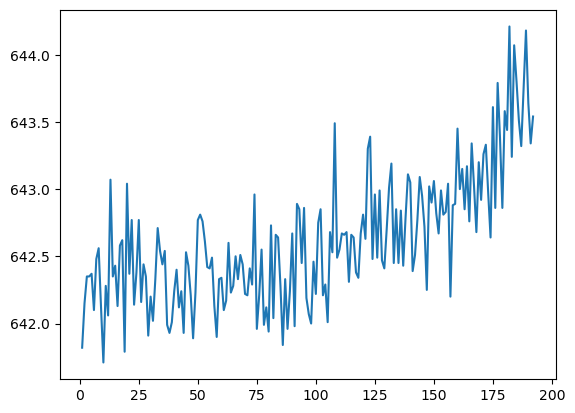

In [20]:
plt.plot(fd1_units[0]['cycle'],fd1_units[0]['s2'])

In [53]:
#Select the first 80 units as training data
df_training = df_1_filtered.drop('RUL',axis=1)
df_training = df_training[df_training['unit_id']<=80]
df_training = df_training.drop(labels=['unit_id','cycle'],axis=1)

df_testing = df_1_filtered.drop('RUL',axis=1)
df_testing = df_testing[df_testing['unit_id']>80]
df_testing = df_testing.drop(labels=['unit_id','cycle'],axis=1)
#Output RUL vector
rul_output = df_1_filtered[df_1_filtered['unit_id']<=80]['RUL']

rul_test = df_1_filtered[df_1_filtered['unit_id']>80]['RUL']

In [54]:
#Testing Linear Regression
reg = LinearRegression().fit(df_training,rul_output)

In [55]:
#Output Linear Regression R^2
reg.score(df_training,rul_output)

0.5934403366062231

In [66]:
#Test on other 20 units
rul_prediction_linear = reg.predict(df_testing)

In [67]:
rul_test

16138    239
16139    238
16140    237
16141    236
16142    235
        ... 
20626      4
20627      3
20628      2
20629      1
20630      0
Name: RUL, Length: 4493, dtype: int64

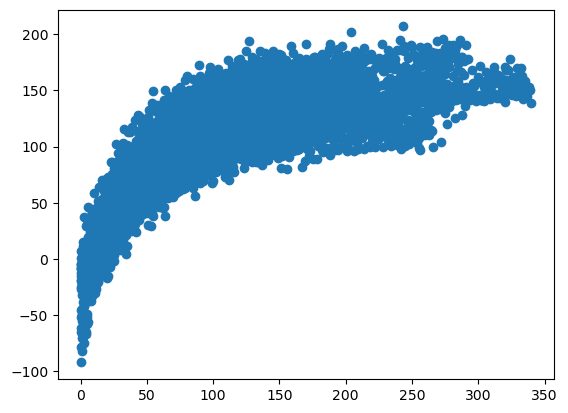

In [68]:
#Plot actual RUL vs. predicted RUL
plt.scatter(rul_test,rul_prediction_linear)

In [59]:
reg.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

In [60]:
#Let's see if Random Forest can improve our odds.

regr = RandomForestRegressor()
regr.fit(df_training,rul_output)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [61]:
rul_prediction = regr.predict(df_testing)

In [62]:
#Significantly higher R^2
regr.score(df_training,rul_output)

0.950856255185735

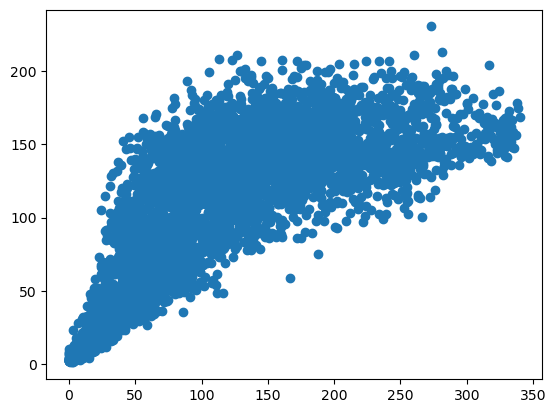

In [64]:
plt.scatter(rul_test,rul_prediction)

In [69]:
#Checking importances of the parameters involved. Looks like element 10 has the highest effect.
regr.feature_importances_

array([0.02052262, 0.01323847, 0.02727324, 0.02618268, 0.07891157,
       0.00068435, 0.03599087, 0.01871411, 0.12528406, 0.45379093,
       0.04572487, 0.02063759, 0.03613856, 0.03160304, 0.00947133,
       0.02354201, 0.03228971])

In [72]:
#Element 10 corresponds to sensor 11
#In agreement with previous paper https://www.sciencedirect.com/org/science/article/pii/S1546221826001104
df_training

,op_set1,op_set2,s2,s3,s4,s6,s7,s8,s9,s11,s12,s13,s14,s15,s17,s20,s21
0,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16133,0.0042,0.0002,644.00,1604.26,1428.92,21.61,552.24,2388.20,9145.62,48.17,520.44,2388.17,8218.63,8.5194,397,38.39,23.1678
16134,-0.0014,0.0004,643.81,1598.32,1426.31,21.61,551.60,2388.16,9160.23,48.41,520.06,2388.12,8221.91,8.5493,396,38.34,23.0142
16135,0.0018,-0.0000,643.49,1603.37,1434.30,21.61,551.78,2388.12,9152.84,48.04,519.67,2388.21,8217.46,8.5106,397,38.34,22.9337
16136,-0.0024,0.0002,643.83,1603.01,1430.23,21.61,551.78,2388.17,9164.10,48.04,519.72,2388.20,8228.65,8.4983,397,38.53,22.9971


In [75]:
#Let's train on the full dataset and try the estimator on the testing data.

#full training data
df_fulltraining = df_1_filtered.drop(labels=['unit_id','cycle','RUL'],axis=1)
rul_output_full = df_1_filtered['RUL']

In [160]:
regr2 = RandomForestRegressor()
regr2.fit(df_fulltraining,rul_output_full)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [161]:
#Check score to make sure no disasters happened
regr2.score(df_fulltraining,rul_output_full)

0.9487604062080394

In [162]:
df1_testfile = pd.read_csv('test_FD001.txt',sep=' ',header=None)
df1_testfile = df1_testfile.dropna(axis=1)
#Name the columns according to the README file for the dataset

columns = ['unit_id','cycle','op_set1','op_set2','op_set3']+[f's{i}' for i in range(1, 22)]
df1_testfile.columns = columns

In [163]:
#Read RUL file. This is the RUL at the end of each unit's readings
rul_testout = pd.read_csv('RUL_FD001.txt',header=None)

In [164]:
df1_testfile = df1_testfile.drop(cols_to_drop,axis=1)


In [171]:
df1_testset = pysqldf("""SELECT * FROM df1_testfile
                         GROUP BY unit_id
                         HAVING cycle=MAX(cycle)
                         """)

In [175]:
df1_testset.sort_values(by='unit_id')

,unit_id,cycle,op_set1,op_set2,s2,s3,s4,s6,s7,s8,s9,s11,s12,s13,s14,s15,s17,s20,s21
0,1,31,-0.0006,0.0004,642.58,1581.22,1398.91,21.61,554.42,2388.08,9056.40,47.23,521.79,2388.06,8130.11,8.4024,393,38.81,23.3552
1,2,49,0.0018,-0.0001,642.55,1586.59,1410.83,21.61,553.52,2388.10,9044.77,47.67,521.74,2388.09,8126.90,8.4505,391,38.81,23.2618
2,3,126,-0.0016,0.0004,642.88,1589.75,1418.89,21.61,552.59,2388.16,9049.26,47.88,520.83,2388.14,8131.46,8.4119,395,38.93,23.2740
3,4,106,0.0012,0.0004,642.78,1594.53,1406.88,21.61,552.64,2388.13,9051.30,47.65,521.88,2388.11,8133.64,8.4634,395,38.58,23.2581
4,5,98,-0.0013,-0.0004,642.27,1589.94,1419.36,21.61,553.29,2388.10,9053.99,47.46,521.00,2388.15,8125.74,8.4362,394,38.75,23.4117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,97,-0.0006,0.0003,642.30,1590.88,1397.94,21.61,553.99,2388.03,9062.41,47.14,522.30,2388.01,8148.24,8.4110,391,38.96,23.4606
96,97,134,0.0013,-0.0001,642.59,1582.96,1410.92,21.61,554.05,2388.06,9076.36,47.38,521.58,2388.06,8155.48,8.4500,395,38.61,23.2953
97,98,121,0.0017,0.0001,642.68,1599.51,1415.47,21.61,553.44,2388.13,9062.34,47.66,521.53,2388.09,8146.39,8.4235,394,38.76,23.3608
98,99,97,0.0047,0.0000,642.00,1585.03,1397.98,21.61,554.75,2388.01,9067.16,47.26,521.82,2388.02,8150.38,8.4003,391,38.95,23.3595


In [176]:
df1_testset = df1_testset.drop(labels=['unit_id','cycle'],axis=1)

In [177]:
#Predicted RUL for the full test dataframe
rul_predicted = regr2.predict(df1_testset)

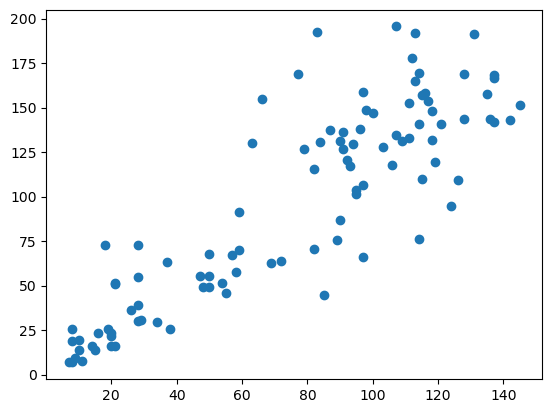

In [178]:
plt.scatter(rul_testout,rul_predicted)

In [179]:
#Scoring against real RUL
regr2.score(df1_testset,rul_testout)

0.3074610526469398

In [181]:
#Score is lower, but the correlation is clearly visible.

In [182]:
regr2.feature_importances_

array([0.02233864, 0.0137847 , 0.02689938, 0.02876561, 0.07972662,
       0.0007293 , 0.03661882, 0.0200945 , 0.12701451, 0.4435086 ,
       0.04720963, 0.02042979, 0.03538172, 0.03326227, 0.00917909,
       0.02356313, 0.03149369])

In [ ]:
#As per before, Sensor 11 is the largest factor.